# Data Collection and Processing


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to dataset
dataset_path = '/content/sample_data/rice_leaf_diseases'

# Image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
NUM_CLASSES = 3  # Adjust according to the dataset

# ImageDataGenerator for preprocessing
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Load train and validation data
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.


# Model Training

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=max(1,train_generator.samples // BATCH_SIZE),
    validation_data=validation_generator,
    validation_steps=max(1,validation_generator.samples // BATCH_SIZE),
    epochs=20
)


Epoch 1/20
3/3 [==============================] - 8s 2s/step - loss: 1.8351 - accuracy: 0.3229 - val_loss: 1.6095 - val_accuracy: 0.4583
Epoch 2/20
3/3 [==============================] - 5s 1s/step - loss: 1.2536 - accuracy: 0.4167 - val_loss: 1.0705 - val_accuracy: 0.3333
Epoch 3/20
3/3 [==============================] - 7s 2s/step - loss: 1.0379 - accuracy: 0.4688 - val_loss: 0.9509 - val_accuracy: 0.7917
Epoch 4/20
3/3 [==============================] - 5s 1s/step - loss: 0.9618 - accuracy: 0.5312 - val_loss: 0.8151 - val_accuracy: 0.7083
Epoch 5/20
3/3 [==============================] - 7s 2s/step - loss: 0.8875 - accuracy: 0.6250 - val_loss: 0.9978 - val_accuracy: 0.5000
Epoch 6/20
3/3 [==============================] - 5s 1s/step - loss: 0.8618 - accuracy: 0.6354 - val_loss: 0.8266 - val_accuracy: 0.6250
Epoch 7/20
3/3 [==============================] - 5s 2s/step - loss: 0.7571 - accuracy: 0.6250 - val_loss: 0.8046 - val_accuracy: 0.6667
Epoch 8/20
3/3 [=========================

# Evaluation

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator, steps=max(1,validation_generator.samples // BATCH_SIZE))
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


1/1 [==============================] - 0s 498ms/step - loss: 1.2050 - accuracy: 0.7500
Validation Accuracy: 75.00%


# Prediction

In [ ]:
from matplotlib import pyplot as plt

1/1 [==============================] - 0s 36ms/step
The predicted class for the image is: Leaf smut


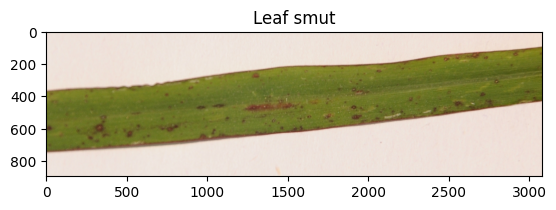

In [ ]:
def predict_image(image_path, model):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = np.expand_dims(img, axis=0) / 255.0
    prediction = model.predict(img)
    class_idx = np.argmax(prediction)
    class_label = list(train_generator.class_indices.keys())[class_idx]
    return class_label

# Example usage
image_path = '/content/sample_data/rice_leaf_diseases/Leaf smut/DSC_0309.JPG'
predicted_class = predict_image(image_path, model)
print(f'The predicted class for the image is: {predicted_class}')
img = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title(predicted_class)
plt.show()
